# Transcript/Question Prompt Generation

In [1]:
from testing_framework import *

stepwise_transcripts = pd.read_csv('./csv/stepwise_transcripts.csv')

truncated = stepwise_transcripts[8 <= stepwise_transcripts['num_ings']][16 > stepwise_transcripts['num_ings']][stepwise_transcripts['transcript'].notna()]

# seed = 42

def df_from_actor_specs(name, pronoun, c, a, p, ir):
    df = {
        'id': [],
        'transcript': []
    }

    for i, t in enumerate(truncated['transcript']):
        actor = Actor(name, pronoun, c, a, p, ir)
        transcript = actor.run_recipe(eval(t))
        df['id'].append(truncated.iloc[:, 0].iloc[i])
        df['transcript'].append(transcript)

    df = pd.DataFrame(df)
    df.set_index('id', inplace=True)
    df.to_csv(f'./results/{name}({pronoun})_c{c}_a{a}_p{p}_i{ir}.csv')

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_43356/2659481068.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[8 <= stepwise_transcripts['num_ings']][16 > stepwise_transcripts['num_ings']][stepwise_transcripts['transcript'].notna()]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_43356/2659481068.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncated = stepwise_transcripts[8 <= stepwise_transcripts['num_ings']][16 > stepwise_transcripts['num_ings']][stepwise_transcripts['transcript'].notna()]


In [23]:
df_from_actor_specs('Alice', 'she', 0.4, 0.4, 0.6, 0.4)

In [3]:
df_from_actor_specs('Bob', 'he', 0.7, 0.4, 0.3, 0.4)

In [4]:
df_from_actor_specs('Charlie', 'he', 0.7, 0.4, 0.6, 0.7)

In [5]:
df_from_actor_specs('Diane', 'they', 0.4, 0.4, 0.3, 0.7)

In [2]:
def mistake_prompt(filepath, n_samples, name=None, ic_ex=True):
    if not name: name = filepath.split('/')[-1].split('(')[0]

    df = pd.read_csv(filepath)
    question_prompt = ''

    if ic_ex:
        question_prompt = f'Below are a set of transcripts describing {name} cooking various recipes, seperated by asterisks:\n'
        question_prompt += '*' * 5 + '\n'

        rows = df.sample(n=n_samples)
        for i, row in rows.iterrows():
            title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += row['transcript']
            question_prompt += '*' * 5 + '\n'
        df.drop(rows.index)
        question_prompt += '\n'

    transcript_row = None
    transcript = ''
    while 'mistake' not in transcript:
        transcript_row = df.sample(1)
        transcript = transcript_row['transcript'].iloc[0]
    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

    # truncate the transcript after the first mistake and ask how the actor will react
    question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        question_prompt += line + '\n'
        if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
    question_prompt += 'Option 1: fix the mistake\n'
    question_prompt += 'Option 2: restart the recipe\n'
    question_prompt += 'Option 3: give up\n\n'

    return question_prompt

print(mistake_prompt('results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv', 5))

Below are a set of transcripts describing Alice cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Mud Puddle Cookies".
Alice creams 1 cup butter, 1 cup sugar and 2 egg yolks, producing some creamed butter-sugar mixture.
Alice whisk 1/4 cup vegetable oil, 1/2 cup cocoa powder, 2 teaspoons vanilla and creamed butter-sugar mixture, producing some cocoa-butter mixture.
Alice blends 2 1/4 cups all-purpose flour and 1/4 teaspoon salt, producing some cookie dough.
Alice notices she made a mistake in step 3.
Alice decides to start over making the recipe.
Alice creams 1 cup butter, 1 cup sugar and 2 egg yolks, producing some creamed butter-sugar mixture.
Alice whisk 1/4 cup vegetable oil, 1/2 cup cocoa powder, 2 teaspoons vanilla and creamed butter-sugar mixture, producing some cocoa-butter mixture.
Alice notices she made a mistake in step 2.
Alice fixes the mistake and continues with the recipe.
Alice blends 2 1/4 cups all-purpose flour and 1/4 teaspoon 

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()


In [2]:
def categorical_prompt(filepath, axis='i', samples_per_actor=3, test_name='Alex'):
    if axis == 'i':
        param = 'irritability'
        low = ['results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv', 'results/Bob(he)_c0.7_a0.4_p0.3_i0.4.csv']
        high = ['results/Charlie(he)_c0.7_a0.4_p0.6_i0.7.csv', 'results/Diane(they)_c0.4_a0.4_p0.3_i0.7.csv']
    else:
        param = 'perfectionism'
        low = ['results/Diane(they)_c0.4_a0.4_p0.3_i0.7.csv',  'results/Bob(he)_c0.7_a0.4_p0.3_i0.4.csv']
        high = ['results/Charlie(he)_c0.7_a0.4_p0.6_i0.7.csv', 'results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv']

    question_prompt = f'You are being tasked with determining if a person making a recipe (heretofore referred to as an "actor") has a high or low degree of {param}.'



    question_prompt += f'Below are a set of transcripts describing actors with low {param} cooking various recipes, seperated by asterisks:\n'
    question_prompt += '*' * 5 + '\n'

    for file in low:
        name = file.split('/')[-1].split('(')[0]
        # sample from file until we find a transcript with mistakes
        df = pd.read_csv(file)
        # print(transcript)

        rows = df.sample(n=samples_per_actor)
        for i, row in rows.iterrows():
            title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += row['transcript']
            question_prompt += '*' * 5 + '\n'

    question_prompt += f'\nBelow are a set of transcripts describing actors with high {param} cooking various recipes, seperated by asterisks:\n'
    question_prompt += '*' * 5 + '\n'

    for file in high:
        name = file.split('/')[-1].split('(')[0]
        # sample from file until we find a transcript with mistakes
        df = pd.read_csv(file)
        # print(transcript)

        rows = df.sample(n=samples_per_actor)
        for i, row in rows.iterrows():
            title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
            question_prompt += f'{name} attempts to make the recipe "{title}".\n'
            question_prompt += row['transcript']
            question_prompt += '*' * 5 + '\n'

    df = pd.read_csv(filepath)
    transcript_row = None
    transcript = ''
    while 'mistake' not in transcript:
        transcript_row = df.sample(1)
        transcript = transcript_row['transcript'].iloc[0]
    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

    # truncate the transcript after the first mistake and ask how the actor will react
    rep_name = filepath.split('/')[-1].split('(')[0]

    question_prompt += f'\nBelow is a transcript of {test_name} making the recipe "{title}":\n'

    question_prompt += transcript.replace(rep_name, test_name) + '\n'

    # for line in transcript.split('\n'):
    #     question_prompt += line + '\n'
    #     if 'mistake' in line: break

    question_prompt += '\n'
    question_prompt += f'Given the transcript, does {test_name} have a high or low degree of {param}? Output only "High" or "Low" (without quotation marks).\n'

    return question_prompt

In [39]:
print(categorical_prompt('results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv'))

You are being tasked with determining if a person making a recipe (heretofore referred to as an "actor") has a high or low degree of irritability.Below are a set of transcripts describing actors with low irritability cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Homemade Candied Orange Peel Bread".
Alice combines 250 grams flour, 5 grams yeast, 25 grams sugar and 1/2 teaspoon salt to taste, producing some flour mixture.
Alice adds 110 milliliters water warm and 1 whole eggs beaten, producing some combined wet mixture.
Alice mixes the 25 grams butter softened, producing some combined mixture.
Alice kneads mixed ingredients and combined mixture, producing some smooth and elastic dough.
Alice notices she made a mistake in step 4.
Alice fixes the mistake and continues with the recipe.
Alice appears calm.
Alice covers the smooth and elastic dough, producing some risen dough.
Alice punches the risen dough, producing some 6 round dough balls.
Alice 

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_96549/451268751.py:53: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()


In [30]:
def categorical_option_prompt(filepath, axis='i', samples_per_actor=3, test_name='Alex'):
    initial = categorical_prompt(filepath, axis=axis, samples_per_actor=samples_per_actor, test_name=test_name)
    if axis == 'i': param = 'irritability'
    else: param = 'perfectionism'

    prompt = initial.split('\nBelow is a transcript of')[0]
    prompt = prompt.replace(f'You are being tasked with determining if a person making a recipe (heretofore referred to as an "actor") has a high or low degree of {param}.', 'You are being tasked with determining if a person ')


    df = pd.read_csv(filepath)
    transcript_row = None
    transcript = ''
    while 'mistake' not in transcript:
        transcript_row = df.sample(1)
        transcript = transcript_row['transcript'].iloc[0]
    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

    val = float(filepath.split(axis)[-1].split('_')[0].split('.')[0])

    # truncate the transcript after the first mistake and ask how the actor will react

    rep_name = filepath.split('/')[-1].split('(')[0]

    prompt += f'\n{test_name} is an actor with a {'low' if val < 0.5 else 'high'} degree of {param}.\n'

    prompt += f'Below is an incomplete transcript of {test_name} making the recipe "{title}":\n'

    for line in transcript.split('\n'):
        prompt += line.replace(rep_name, test_name) + '\n'
        if 'mistake' in line: break

    # name = filepath.split('/')[-1].split('(')[0]
    # prompt += mistake_prompt(filepath, samples_per_actor).replace(name, test_name)

    prompt += '\n'
    prompt += f'Given the following options, which option best represents how {name} will react?\n'
    prompt += 'Option 1: fix the mistake\n'
    prompt += 'Option 2: restart the recipe\n'
    prompt += 'Option 3: give up\n\n'

    return prompt

In [31]:
print(categorical_option_prompt('results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv'))

You are being tasked with determining if a person Below are a set of transcripts describing actors with low irritability cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Pita Nachos ".
Alice toasts the ~1/4 cup of slivered almonds, producing some toasted almonds.
Alice heats ~1 can black beans drained and ~1 cup of cooked israeli couscous (cook in chicken stock), producing some heated black beans and couscous.
Alice notices she made a mistake in step 2.
Alice decides to start over making the recipe.
Alice toasts the ~1/4 cup of slivered almonds, producing some toasted almonds.
Alice heats ~1 can black beans drained and ~1 cup of cooked israeli couscous (cook in chicken stock), producing some heated black beans and couscous.
Alice scoop the ~1 ripe avocado, producing some scooped avocado.
Alice mash the scooped avocado, producing some mashed avocado.
Alice mixes the ~juice from 1/2 lemon, producing some mixed ingredients.
Alice stir the ~8-10 che

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_4367/1189543866.py:53: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_4367/2885996391.py:16: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()


# Testing

In [11]:
def test(prompt,
         num_samples = 50,
         model=None):
    outputs = {}
    full_outputs = {}

    full_list = []
    if model is None:
        full_list.extend(openai_list)
        full_list.extend(together_list)
    else:
        full_list.append(model)

    for model in full_list:
        outputs[model] = []
        full_outputs[model] = []

    for _ in tqdm(range(num_samples)):

        for model in full_list:
            try:
                if model in openai_list:
                    client = OpenAI()
                    response = client.responses.create(
                        model=model,
                        # instructions=instructions,
                        # input=instructions + transcript_text + mistake_text,
                        input = prompt,
                        reasoning={"effort": 'medium', "summary": "auto"}
                    )
                    output = response.output_text
                    full_output = response
                    # reasoning[ing].append(response.output[0].summary[0].text)
                else:
                    client = Together()
                    response = client.chat.completions.create(
                        model=model,
                        messages=[
                            # {"role": "user", "content": instructions},
                            # {"role": "user", "content": instructions + transcript_text + mistake_text}
                            {"role": "user", "content": prompt}
                        ],
                        reasoning={"enabled": True},
                        max_tokens=30000,
                        timeout=600
                    )
                    output = response.choices[0].message.content
                    full_output = response
            except Exception as e:
                print(f'Error: {str(e)} ({model})')
                output = 'timeout'
                full_output = 'timeout'

            outputs[model].append(output)
            full_outputs[model].append(full_output)


    return outputs, full_outputs

In [13]:
metadata = {
    'full': [],
    'no_ic': [],
    'description': []
}

for i in range(5):
    full_prompt = mistake_prompt('results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv', n_samples=5)
    no_ic_prompt = full_prompt.split('*\n\n')[-1]
    description_prompt = 'Alice is a calm perfectionist. ' + no_ic_prompt
    print(full_prompt)
    print(no_ic_prompt)
    print(description_prompt)

    metadata['full'].append(full_prompt)
    metadata['no_ic'].append(no_ic_prompt)
    metadata['description'].append(description_prompt)

meta_df = pd.DataFrame.from_dict(metadata)
# meta_df.to_csv('results/Alice_metadata.csv', index=False)

Below are a set of transcripts describing Alice cooking various recipes, seperated by asterisks:
*****
Alice attempts to make the recipe "Betty's Zucchini Bread".
Alice sift 2 cups flour, 2-3 teaspoons cinnamon, 2 teaspoons baking soda, 1 teaspoon salt and 1/2 teaspoon baking powder, producing some dry ingredients.
Alice notices she made a mistake in step 1.
Alice fixes the mistake and continues with the recipe.
Alice beat the 3 large eggs, producing some beaten eggs.
Alice notices she made a mistake in step 2.
Alice decides to start over making the recipe.
Alice appears calm.
Alice sift 2 cups flour, 2-3 teaspoons cinnamon, 2 teaspoons baking soda, 1 teaspoon salt and 1/2 teaspoon baking powder, producing some dry ingredients.
Alice beat the 3 large eggs, producing some beaten eggs.
Alice beat 2 cups sugar and beaten eggs, producing some thick lemon-colored mixture.
Alice beats 3/4 cup vegetable oil and thick lemon-colored mixture, producing some well-beaten mixture.
Alice notices she

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_89551/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_89551/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_89551/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/

In [17]:
metadata = {
    'full': [],
    'no_ic': [],
    'description': []
}

for i in range(10):
    full_prompt = mistake_prompt('results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv', n_samples=5)
    no_ic_prompt = full_prompt.split('*\n\n')[-1]
    description_prompt = 'Alice is a calm perfectionist. ' + no_ic_prompt
    # print(full_prompt)
    # print(no_ic_prompt)
    # print(description_prompt)

    metadata['full'].append(full_prompt)
    metadata['no_ic'].append(no_ic_prompt)
    metadata['description'].append(description_prompt)

extended = pd.DataFrame.from_dict(metadata)
meta_df = pd.read_csv('results/Alice_metadata.csv')
combined = pd.concat([meta_df, extended], axis=0)
# combined
combined.to_csv('results/Alice_metadata.csv', index=False)

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_75150/12882069.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/

In [8]:
def get_mixed_metadata(filename, n=20):
    files = [
        'results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv',
        'results/Bob(he)_c0.7_a0.4_p0.3_i0.4.csv',
        'results/Charlie(he)_c0.7_a0.4_p0.6_i0.7.csv',
        'results/Diane(they)_c0.4_a0.4_p0.3_i0.7.csv'
    ]
    others = [file for file in files if file != filename]

    def mixed_prompt(filepath, n_samples, name=None, ic_ex=True):
        # df = pd.read_csv(filepath)
        question_prompt = ''

        if ic_ex:
            question_prompt = f'Below are a set of transcripts describing actors cooking various recipes, seperated by asterisks:\n'
            question_prompt += '*' * 5 + '\n'
            for _ in range(n_samples):
                file = random.choice(others)
                name = file.split('/')[-1].split('(')[0]
                df = pd.read_csv(file)

                rows = df.sample(n=1)
                for i, row in rows.iterrows():
                    title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(row['id'])]['title'].item()
                    question_prompt += f'{name} attempts to make the recipe "{title}".\n'
                    question_prompt += row['transcript']
                    question_prompt += '*' * 5 + '\n'
                df.drop(rows.index)

        question_prompt += '\n'

        df = pd.read_csv(filepath)
        name = filepath.split('/')[-1].split('(')[0]

        transcript_row = None
        transcript = ''
        while 'mistake' not in transcript:
            transcript_row = df.sample(1)
            transcript = transcript_row['transcript'].iloc[0]
        title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()

        # truncate the transcript after the first mistake and ask how the actor will react
        question_prompt += f'Below is an incomplete transcript of {name} making the recipe "{title}":\n'

        for line in transcript.split('\n'):
            question_prompt += line + '\n'
            if 'mistake' in line: break

        question_prompt += '\n'
        question_prompt += f'Given the following options, which option best represents how {name} will react?\n'
        question_prompt += 'Option 1: fix the mistake\n'
        question_prompt += 'Option 2: restart the recipe\n'
        question_prompt += 'Option 3: give up\n\n'

        return question_prompt

    metadata = pd.read_csv('results/Alice_metadata.csv')

    mixed_prompts = []

    for i in range(n): mixed_prompts.append(mixed_prompt(filename, n_samples=5))

    metadata['mixed_prompts'] = mixed_prompts

    # extended = pd.DataFrame.from_dict(metadata)
    # meta_df = pd.read_csv('results/Alice_metadata.csv')
    # combined = pd.concat([meta_df, extended], axis=0)
    # # combined
    metadata.to_csv('results/Alice_metadata.csv', index=False)
    return metadata

get_mixed_metadata('results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv')

/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_43356/3419534848.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_43356/3419534848.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].item()
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_43356/3419534848.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  title = stepwise_transcripts.loc[stepwise_transcripts.iloc[:, 0] == int(transcript_row['id'])]['title'].it

,full,no_ic,description,mixed_prompts
0,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
1,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
2,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
3,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
4,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
5,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
6,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
7,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
8,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...
9,Below are a set of transcripts describing Alic...,Below is an incomplete transcript of Alice mak...,Alice is a calm perfectionist. Below is an inc...,Below are a set of transcripts describing acto...


In [9]:
def run_prompt(prompt,
               test_name,
               metadata_index,
               num_samples = 20,
               filename = 'results/Alice(she)_c0.4_a0.4_p0.6_i0.4.csv'):
    name = filename.split('/')[-1].split('(')[0]

    # print(prompt)

    result = test(prompt, num_samples)

    outputs, full_outputs = result

    dataroot = f'./results/n{num_samples}_{name}_n5_{test_name}'

    try: os.mkdir(dataroot)
    except OSError as e: pass

    out_df = pd.DataFrame(outputs)
    full_df = pd.DataFrame(full_outputs)

    out_df.to_csv(f'{dataroot}/outputs{metadata_index}.csv', index=False)
    full_df.to_csv(f'{dataroot}/full_outputs{metadata_index}.csv', index=False)

meta_df = pd.read_csv('results/Alice_metadata.csv')

In [18]:
for i in range(len(meta_df)):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[i+10], 'fulltest', i+10)

100%|██████████| 20/20 [53:35<00:00, 160.79s/it]


In [23]:
for i in range(6):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['no_ic'].iloc[i+14], 'noIC', i+14)

100%|██████████| 20/20 [23:22<00:00, 70.13s/it]


In [25]:
for i in range(17):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['description'].iloc[i+5], 'description', i+5)

100%|██████████| 20/20 [26:52<00:00, 80.61s/it]


IndexError: single positional indexer is out-of-bounds

In [13]:
for i in range(20):
    run_prompt(pd.read_csv('results/Alice_metadata.csv')['mixed_prompts'].iloc[i], 'mixed_prompts', i)

  5%|▌         | 1/20 [03:05<58:47, 185.64s/it]


KeyboardInterrupt: 

In [62]:
from together import Together
import numpy as np

client = Together()

line = pd.read_csv('results/Alice_metadata.csv')['full'].iloc[0] + 'OUTPUT ONLY THE OPTION NUMBER AND NOTHING ELSE.'

completion = client.chat.completions.create(
    model="Qwen/Qwen3.5-9B",
    reasoning={"enabled": False},
    messages=[
        {
            "role": "user",
            "content": line,
        }
    ],
    max_tokens=1,
    logprobs=10,
)

probs = np.zeros(4)

for dict in completion.choices[0].logprobs.content[0]['top_logprobs']:
    if dict['token'] in ['1','2','3']: probs[int(dict['token'])] = np.exp(dict['logprob'])

print(probs)
probs = probs / np.sum(probs)
probs

[0.         0.25888501 0.02125058 0.01460529]


array([0.        , 0.87834783, 0.07209918, 0.04955299])

In [111]:
def run_prompt_logprob(prompt,
               model="Qwen/Qwen3.5-9B",):
    completion = client.chat.completions.create(
        model=model,
        reasoning={"enabled": False},
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        max_tokens=1,
        logprobs=10,
    )

#Logit bias: https://docs.together.ai/reference/completions#body-logit-bias  - only allow certain tokens

    probs = np.zeros(4)

    for dict in completion.choices[0].logprobs.content[0]['top_logprobs']:
        if dict['token'] in ['1','2','3']: probs[int(dict['token'])] = np.exp(dict['logprob'])

    # print(completion.choices[0])
    probs = probs / np.sum(probs)
    return probs

meta_df = pd.read_csv('results/Alice_metadata.csv')

In [112]:
probs = run_prompt_logprob(pd.read_csv('results/Alice_metadata.csv')['full'].iloc[0] +
                                   'OUTPUT ONLY THE OPTION NUMBER AND NOTHING ELSE.', "Qwen/Qwen3.5-397B-A17B")

In [116]:
results = {}
for column in meta_df.columns:
    all_probs = []
    print(f'Running {column}:')
    for i in tqdm(range(len(meta_df))):
        probs = run_prompt_logprob(pd.read_csv('results/Alice_metadata.csv')[column].iloc[i] +
                                   'OUTPUT ONLY THE OPTION NUMBER AND NOTHING ELSE.', "Qwen/Qwen3.5-397B-A17B")
        all_probs.append(probs)
    all_probs = np.stack(all_probs)
    mean = np.mean(all_probs, axis=0)
    sd = np.std(all_probs, axis=0) / np.sqrt(len(all_probs))
    results[column] = (mean, sd)

Running full:


100%|██████████| 20/20 [00:09<00:00,  2.11it/s]


Running no_ic:


100%|██████████| 20/20 [00:08<00:00,  2.43it/s]


Running description:


100%|██████████| 20/20 [00:08<00:00,  2.48it/s]


In [90]:
all_probs

array([[0.        , 0.70331398, 0.20150283, 0.09518319],
       [0.        , 0.25831504, 0.61966557, 0.12201939],
       [0.        , 0.36929926, 0.53732726, 0.09337348],
       [0.        , 0.83115706, 0.12746207, 0.04138087],
       [0.        , 0.54865935, 0.37708769, 0.07425296],
       [0.        , 0.6141465 , 0.32872897, 0.05712452],
       [0.        , 0.84798063, 0.1147617 , 0.03725767],
       [0.        , 0.55782136, 0.38338469, 0.05879395],
       [0.        , 0.69927542, 0.2270215 , 0.07370308],
       [0.        , 0.37708771, 0.54865932, 0.07425296],
       [0.        , 0.3363183 , 0.55449514, 0.10918655],
       [0.        , 0.56821875, 0.34464207, 0.08713917],
       [0.        , 0.36929926, 0.53732726, 0.09337348],
       [0.        , 0.63882207, 0.30175822, 0.05941971],
       [0.        , 0.75979491, 0.16953316, 0.07067194],
       [0.        , 0.80794907, 0.14040048, 0.05165045],
       [0.        , 0.57938646, 0.35141569, 0.06919784],
       [0.        , 0.81728661,

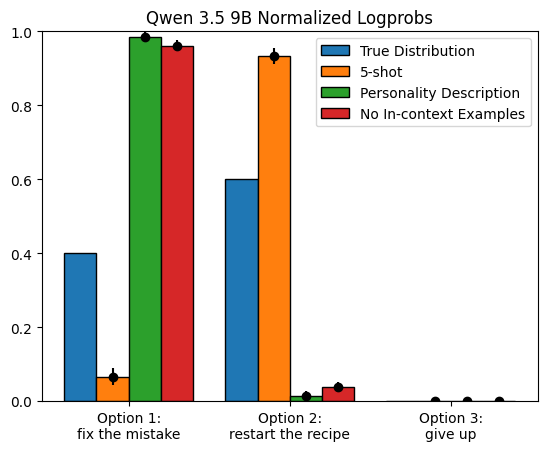

In [117]:
import matplotlib.pyplot as plt

true_dist = {
    'Option 1': 0.4,
    'Option 2': 0.6,
    'Option 3': 0
}

test_names = [
    '5-shot',
    'Personality Description',
    'No In-context Examples',
]

plt.bar(np.array(range(len(true_dist))) - 0.3, true_dist.values(), width=0.2, align='center', edgecolor='black', label='True Distribution')

i = 0
for column, (mean, sd) in results.items():
    scale = np.array(range(len(true_dist))) + (i+1) * 0.2 - 0.3
    plt.bar(scale, mean[1::], width=0.2, align='center', edgecolor='black', label=test_names[i])
    plt.errorbar(scale, mean[1::], yerr = sd[1::], fmt ='o', color='black')
    i += 1

plt.ylim([0, 1])
plt.title('Qwen 3.5 9B Normalized Logprobs')
plt.xticks(np.arange(len(true_dist)), ['Option 1:\nfix the mistake', 'Option 2:\nrestart the recipe', 'Option 3:\ngive up'], rotation=0)
plt.legend()
plt.show()

# 5 shot with other agents, +- personality descriptions in ic
# research questions

# Visualization

In [15]:
import math
import re

def distribution(columns):
    dist = {
        'Option 1': [],
        'Option 2': [],
        'Option 3': []
    }

    for c in columns:
        d = {
            'Option 1': 0,
            'Option 2': 0,
            'Option 3': 0
        }

        for response in c:
            res = re.search(r"\d{1} noitpO", response[::-1])
            if res: d[res.group()[::-1]] += 1

        for option in d: dist[option].append(d[option] / len(c))

    mean = {}
    sd = {}
    for option in dist:
        mean[option] = sum(dist[option]) / len(dist[option])
        sd[option] = math.sqrt(mean[option]*(1-mean[option])/len(columns))

    return mean, sd

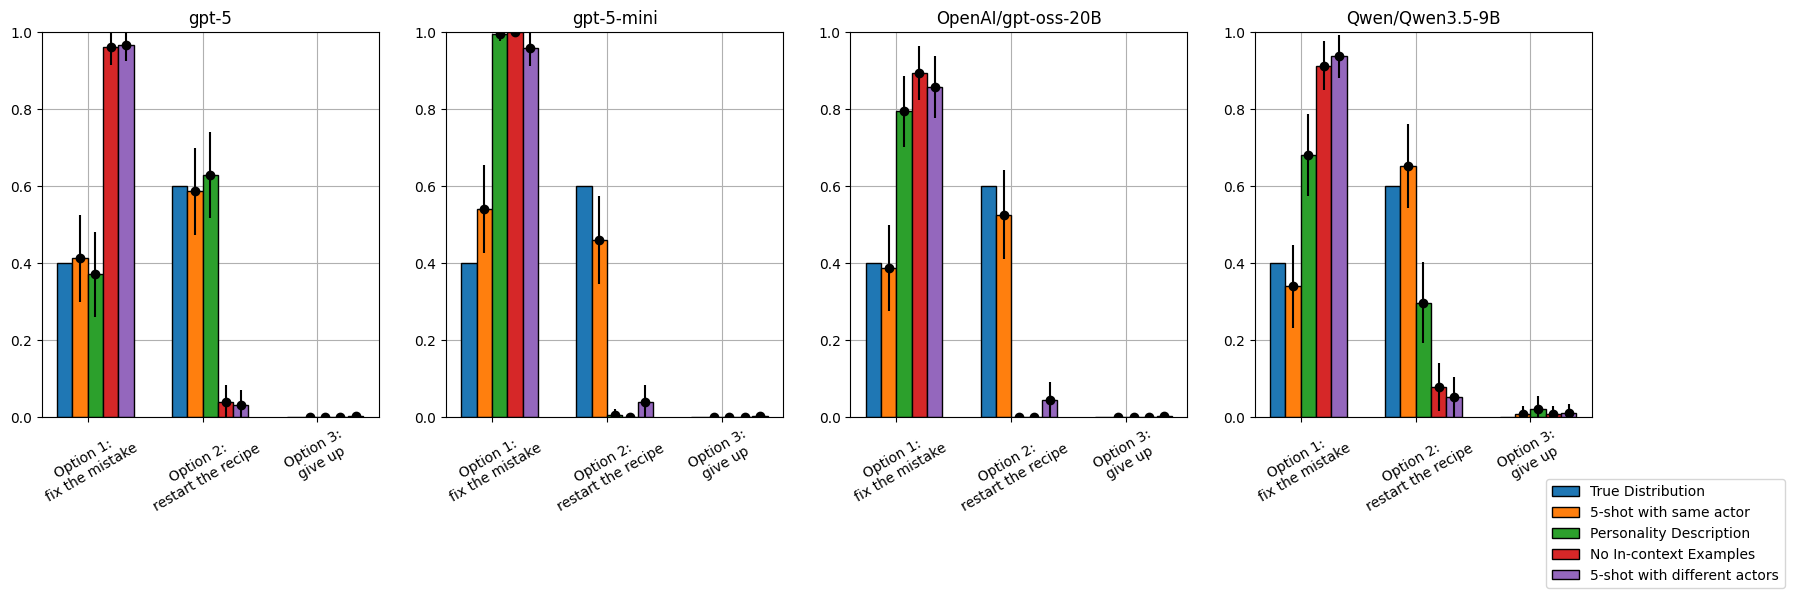

In [23]:
import numpy as np
import matplotlib.pyplot as plt

tests = [
    'results/n20_Alice_n5_fulltest',
    'results/n20_Alice_n5_description',
    'results/n20_Alice_n5_noIC',
    'results/n20_Alice_n5_mixed_prompts',
]

test_names = [
    '5-shot with same actor',
    'Personality Description',
    'No In-context Examples',
    '5-shot with different actors',
]

true_dist = {
    'Option 1': 0.4,
    'Option 2': 0.6,
    'Option 3': 0
}

full_list = openai_list + together_list

# print(full_list)

between_scaling = 1.5

fig, ax = plt.subplots(nrows=1, ncols=len(full_list), figsize=(20, 5))

for i, model in enumerate(full_list):
    ax[i].bar(between_scaling * np.array(range(len(true_dist))) - 0.3, true_dist.values(), width=0.2, align='center', edgecolor='black', label='True Distribution')
    for j, folder in enumerate(tests):
        columns = [pd.read_csv(f'{folder}/outputs{i}.csv')[model] for i in range(19)]
        # column = pd.read_csv(f'{folder}/outputs.csv')[model]
        mean, sd = distribution(columns)
        scale = between_scaling * np.array(range(len(mean))) + (j+1) * 0.2 - 0.3
        ax[i].bar(scale, mean.values(), width=0.2, align='center', edgecolor='black', label=test_names[j])
        ax[i].errorbar(scale, mean.values(), yerr = sd.values(), fmt ='o', color='black')
    # ax[i].set_xticks(np.array(range(len(true_dist))), true_dist.keys(), rotation=30)
    ax[i].set_xticks(between_scaling * np.array(range(len(true_dist))), ['Option 1:\nfix the mistake', 'Option 2:\nrestart the recipe', 'Option 3:\ngive up'], rotation=30)
    ax[i].set_title(model)
    ax[i].set_ylim(0, 1)
    ax[i].grid(True)
    ax[i].set_axisbelow(True)
    # ax[i].legend()
    # ax[i].set_

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1, 0))

plt.show()

# Evaluation

In [65]:
file = 'results_missing_ing/t4_n16_l4_s0_(8,16)/full_outputs.csv'
col = 0
i = 1

col_to_read = pd.read_csv(file).iloc[:, col]

class Summary:
    def __init__(self, text, type):
        self.text = text
        self.type = type

    def __repr__(self):
        return self.text

In [71]:
print(eval(col_to_read[6].split("summary=")[1].split(", type='reasoning'")[0]))
i += 1

[**Analyzing Alice's recipe**

I'm trying to identify which recipe Alice is making based on her ingredients and steps. She melts semi-sweet morsels, creams butter and sugar, and mixes in baking soda. Various recipes fit these ingredients, but melting the chips seems unusual for traditional chocolate chip cookies. It might indicate she’s making some bars or fudge. It seems likely this is a variation of a chocolate chip cookie, but I need to narrow it down to the correct recipe number., **Identifying the recipe**

I'm considering if Alice could be making chocolate swirl cookies. The mix of baking soda causes a bit of confusion, which makes me wonder if she accidentally used baking powder instead. It's essential to figure out if there's a recipe that matches her ingredients and skips vanilla, as she hasn't used it so far. It looks like many recipes require melting chocolate chips for unique bases, especially in recipes with heavy cream or other unusual ingredients that might need that., *